# Detección Automática de Crisis Epilépticas a partir de Electroencefalogramas (EEG)

# Identificación del problema

**Definiciones importantes**

* **[Epilepsia](https://es.wikipedia.org/wiki/Epilepsia)**: es una enfermedad provocada por un desequilibrio en la actividad eléctrica de las neuronas de alguna zona del cerebro. Una convulsión o crisis epiléptica es un evento súbito y de corta duración, caracterizado por una actividad neuronal anormal y excesiva o bien sincrónica en el cerebro.
* **[Electroencefalograma (EEG)](https://es.wikipedia.org/wiki/Electroencefalografia)**: es una exploración neurofisiológica que se basa en el registro de la actividad bioeléctrica cerebral en condiciones basales de reposo, en vigilia o sueño, y durante diversas activaciones mediante un equipo de electroencefalografía.


**Contexto del problema**

Cuando un paciente sufre de crisis epilépticas, a menudo es sometido a un monitoreo constante para registrar su actividad cerebral realizando Electroencefalogramas. La epilepsia es un evento paroxístico (es decir, que ocurre intermitentemente), por lo que para capturar una crisis o la actividad interictal (entre crisis), es necesario monitorear al paciente durante varias horas. Si el paciente sufriera una convulsión en algún momento durante el monitoreo, sería conveniente contar con un sistema que procese en tiempo real los datos del EEG y alerte al personal médico inmediatamente cuando se detecte un patrón de crisis epiléptica. Esto permite una intervención a tiempo para tratar al paciente.

**Pregunta a responder**

*Dado 1 segundo de actividad cerebral tomado de un EEG, ¿muestra el segmento un patrón indicativo de una crisis epiléptica?*

**Objetivos**
1. Que el modelo aprenda a distinguir el patrón de actividad cerebral asociado a una crisis epiléptica de cualquier otra forma de actividad cerebral no epiléptica.
3. El modelo no puede no detectar si un paciente está convulsionando. Es preferible alertar aun así esté equivocado.
4. La velocidad en la detección es crítica, por lo que el tiempo en procesar los datos y generar la predicción debe ser bajo.
   
**Definiciones para comprender las métricas de rendimiento**
 * **Ejemplo**: hace referencia al segmento de actividad cerebral registrado en el conjunto de datos.
 * **Clase positiva/negativa**: es la categoría a la que pertenece el ejemplo, que puede ser un patrón de actividad cerebral correspondiente a una crisis epiléptica (clase positiva) o a una actividad no epiléptica (clase negativa).
   
**Métricas de rendimiento deseadas**

1. **Accuracy (exactitud)**: que muestra la cantidad de ejemplos clasificados correctamente sobre el total de ejemplos del conjunto de datos. Éste valor debe ser alto, por lo que un umbral mayor o igual a 95% es un requisito fundamental.
2. **Matriz de confusión:** que muestra la cantidad de ejemplos de cada clase clasificados correcta e incorrectamente. Se desea que los ejemplos clasificados correctamente superen a los categorizados erróneamente.

De la matriz de confusión, se debe identificar cuáles son las métricas que importan que el modelo obtenga buenos resultados:
- **Verdadero Positivo**: paciente que está sufriendo una crisis y que el modelo predice que está teniendo una. Este es el acierto más importante.
- **Falso Negativo**: paciente que está convulsionando pero el modelo no lo detecta. Este es el peor error que puede cometer.
- **Falso Positivo**: paciente que no está sufriendo una crisis pero el modelo predice que sí lo está. Este es un error secundario.
- **Verdadero Negativo**: paciente que no está convulsionando y el modelo predice que no lo está. Esto es un acierto.

Sobre las matrices de confusión, se obtienen las siguientes métricas:
- **Precisión**: calcula la cantidad de ejemplos de la clase positiva clasificados correctamente sobre el total de ejemplos estimados como positivos.
- **Recall**:  calcula la cantidad de ejemplos de la clase positiva clasificados correctamente sobre el total de ejemplos que pertenecen a la clase positiva.

Entonces, lo que se buscará es un modelo que presente alto Recall, para que la mayoría de pacientes que estén sufriendo un episodio epiléptico sean detectados, aún si se alerte equivocadamente de pacientes que no estén convulsionando  (baja proporción de "Falso Negativo"). Al enfocarse en el Recall, se sacrifica la Precisión en detectar pacientes que realmente están sufriendo una crisis (alta proporción de "Falso Positivo").

# Obtención del conjunto de datos

El conjunto de datos contiene 11.500 ejemplos de actividad cerebral provenientes de 500 pacientes. Cada fila representa un fragmento de 1 segundo de un Electroencefalograma (EEG). Cada columna es un punto de datos que registra el valor del EEG en un momento diferente dentro de ese segundo, capturando la forma de la onda cerebral.

* **Variables explicativas/Características (X1-X178)**: 178 características de la señal EEG.
* **Variable de respuesta/Etiqueta (y)**: categoriza las grabaciones de EEG en 5 categorías. La clase 1 indica una crisis epiléptica, mientras que las clases 2, 3, 4 y 5 corresponden a actividad cerebral no epiléptica bajo diferentes condiciones (actividad cerebral de los pacientes registrada cuando tenían los ojos abiertos, cerrados, región del cerebro donde se encontraba un tumor y zona sana lejos del tumor).

La idea será adaptar el dataset para resolver un problema de clasificación binaria con Aprendizaje Supervisado. El objetivo es predecir si el segmento de actividad cerebral muestra una crisis epiléptica (clase 1) o no.

In [ ]:
import pandas as pd

# Importamos el conjunto de datos
data = pd.read_csv('Epileptic Seizure Recognition.csv')

# Exploración de los datos

In [ ]:
# Imprimimos el conjunto de datos
display(data)

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11495,X22.V1.114,-22,-22,-23,-26,-36,-42,-45,-42,-45,...,15,16,12,5,-1,-18,-37,-47,-48,2
11496,X19.V1.354,-47,-11,28,77,141,211,246,240,193,...,-65,-33,-7,14,27,48,77,117,170,1
11497,X8.V1.28,14,6,-13,-16,10,26,27,-9,4,...,-65,-48,-61,-62,-67,-30,-2,-1,-8,5
11498,X10.V1.932,-40,-25,-9,-12,-2,12,7,19,22,...,121,135,148,143,116,86,68,59,55,3


In [ ]:
# Imprimimos la información del conjunto de datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Columns: 180 entries, Unnamed to y
dtypes: int64(179), object(1)
memory usage: 15.8+ MB


Observar que **dtypes** indica que hay una columna que no es numérica. Esta es la columna "Unnamed" que no aporta datos relevantes al problema e introduce ruido al conjunto de datos, por lo que hay que eliminarla en la limpieza del dataset.

In [ ]:
# Imprimimos el resumen estadístico
data.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
count,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.00000,11500.00000,11500.000000,...,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000
mean,-11.581391,-10.911565,-10.187130,-9.143043,-8.009739,-7.003478,-6.502087,-6.68713,-6.55800,-6.168435,...,-10.145739,-11.630348,-12.943478,-13.668870,-13.363304,-13.045043,-12.705130,-12.426000,-12.195652,3.000000
std,165.626284,166.059609,163.524317,161.269041,160.998007,161.328725,161.467837,162.11912,162.03336,160.436352,...,164.652883,166.149790,168.554058,168.556486,167.257290,164.241019,162.895832,162.886311,164.852015,1.414275
min,-1839.000000,-1838.000000,-1835.000000,-1845.000000,-1791.000000,-1757.000000,-1832.000000,-1778.00000,-1840.00000,-1867.000000,...,-1867.000000,-1865.000000,-1642.000000,-1723.000000,-1866.000000,-1863.000000,-1781.000000,-1727.000000,-1829.000000,1.000000
25%,-54.000000,-55.000000,-54.000000,-54.000000,-54.000000,-54.000000,-54.000000,-55.00000,-55.00000,-54.000000,...,-55.000000,-56.000000,-56.000000,-56.000000,-55.000000,-56.000000,-55.000000,-55.000000,-55.000000,2.000000
50%,-8.000000,-8.000000,-7.000000,-8.000000,-8.000000,-8.000000,-8.000000,-8.00000,-7.00000,-7.000000,...,-9.000000,-10.000000,-10.000000,-10.000000,-10.000000,-9.000000,-9.000000,-9.000000,-9.000000,3.000000
75%,34.000000,35.000000,36.000000,36.000000,35.000000,36.000000,35.000000,36.00000,36.00000,35.250000,...,34.000000,34.000000,33.000000,33.000000,34.000000,34.000000,34.000000,34.000000,34.000000,4.000000
max,1726.000000,1713.000000,1697.000000,1612.000000,1518.000000,1816.000000,2047.000000,2047.00000,2047.00000,2047.000000,...,1777.000000,1472.000000,1319.000000,1436.000000,1733.000000,1958.000000,2047.000000,2047.000000,1915.000000,5.000000


El dataset así como está presenta dos inconvenientes para resolver el problema de clasificación binaria:
1. La etiqueta "y" es multiclase, por lo que deberá ser adaptada para que sea binaria.
2. Los rangos de valores de las características son muy amplios, lo cual puede afectar el rendimiento de los modelos de Aprendizaje Supervisado (observar que el valor mínimo y el máximo de las características son muy distantes).

# EDA: Pre-procesamiento y análisis exploratorio de datos

## Limpieza y transformación

Se realizarán las siguientes transformaciones al dataset:
1. Eliminar la columna no numérica "Unnamed".
2. Transformar la etiqueta multivariada a binaria.
3. Definir las características y la etiqueta en dos variables.
4. Normalizar los datos. Este paso se implementará luego de dividir los datos en porciones para entrenamiento y testeo.

In [ ]:
import numpy as np

df = pd.DataFrame(data)

# Paso 1 - Quitar la columna Unnamed
df = df.drop(['Unnamed'], axis=1)

# Paso 2 - Transformar la etiqueta multiclase para que sea binaria
df['y'] = np.where(df['y'] == 1, 1, 0)

# Paso 3.1 - Definir los features
df_data = df.drop('y', axis=1)

# Paso 3.2 - Definir el label
df_label = df['y']

In [ ]:
# Imprimimos la información del conjunto de datos
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Columns: 178 entries, X1 to X178
dtypes: int64(178)
memory usage: 15.6 MB


In [ ]:
# Imprimimos los primeros 10 ejemplos
display(df_data.head(10))

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X169,X170,X171,X172,X173,X174,X175,X176,X177,X178
0,135,190,229,223,192,125,55,-9,-33,-38,...,8,-17,-15,-31,-77,-103,-127,-116,-83,-51
1,386,382,356,331,320,315,307,272,244,232,...,168,164,150,146,152,157,156,154,143,129
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,29,57,64,48,19,-12,-30,-35,-35,-36
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-80,-82,-81,-80,-77,-85,-77,-72,-69,-65
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,10,4,2,-12,-32,-41,-65,-83,-89,-73
5,55,28,18,16,16,19,25,40,52,66,...,-6,-12,-31,-42,-54,-60,-64,-60,-56,-55
6,-55,-9,52,111,135,129,103,72,37,0,...,-137,-125,-99,-79,-62,-41,-26,11,67,128
7,1,-2,-8,-11,-12,-17,-15,-16,-18,-17,...,-67,-79,-91,-97,-88,-76,-72,-66,-57,-39
8,-278,-246,-215,-191,-177,-167,-157,-139,-118,-92,...,-386,-400,-379,-336,-281,-226,-174,-125,-79,-40
9,8,15,13,3,-6,-8,-5,4,25,41,...,65,49,31,11,-5,-17,-19,-15,-15,-11


In [ ]:
# Imprimimos los últimos 10 ejemplos
display(df_data.tail(10))

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X169,X170,X171,X172,X173,X174,X175,X176,X177,X178
11490,-22,-64,-121,-201,-292,-336,-398,-527,-773,-1069,...,354,183,-152,-499,-577,-415,-223,-88,-18,-61
11491,102,137,158,158,128,92,60,56,63,63,...,92,76,64,59,44,39,23,11,4,2
11492,-27,-53,-84,-104,-131,-171,-199,-203,-177,-142,...,-136,-127,-114,-99,-79,-56,-28,-14,-8,-12
11493,-136,-137,-138,-135,-130,-123,-116,-118,-119,-119,...,-11,-1,3,5,8,13,16,24,34,42
11494,-39,-16,-13,-14,-68,-84,-92,-61,-89,-86,...,-88,-102,-75,-63,-44,-66,-49,-34,-31,-52
11495,-22,-22,-23,-26,-36,-42,-45,-42,-45,-49,...,20,15,16,12,5,-1,-18,-37,-47,-48
11496,-47,-11,28,77,141,211,246,240,193,136,...,-94,-65,-33,-7,14,27,48,77,117,170
11497,14,6,-13,-16,10,26,27,-9,4,14,...,-42,-65,-48,-61,-62,-67,-30,-2,-1,-8
11498,-40,-25,-9,-12,-2,12,7,19,22,29,...,114,121,135,148,143,116,86,68,59,55
11499,29,41,57,72,74,62,54,43,31,23,...,-94,-59,-25,-4,2,5,4,-2,2,20


In [ ]:
# Imprimimos la cantidad de ejemplos y características del dataset
print( 'Cantidad de...' )
print( f"Ejemplos: {df_data.shape[0]}" )
print( f"Features: {df_data.shape[1]}" )

Cantidad de...
Ejemplos: 11500
Features: 178


In [ ]:
# Imprimimos la cantidad de ejemplos por clase
print( f"Cantidad de ejemplos por clase: \n{ df_label.value_counts().rename({0:'No crisis',1:'Crisis'}) }" )

Cantidad de ejemplos por clase: 
y
No crisis    9200
Crisis       2300
Name: count, dtype: int64


Observación: el dataset está desbalanceado, cuenta con el cuádruple de ejemplos de la clase negativa ("No crisis") que de la clase positiva ("Crisis"), esto se debe a la unificación de las cuatro categorías a una única clase.

## Análisis exploratorio

Se creará el siguiente gráfico de la librería Seaborn para observar la distribución de los datos:
- **Pairplot**: grafica los ejemplos de a pares de features. Con estos gráficos se puede observar si existe tendencia de separabilidad lineal entre los datos y evaluar si es posible implementar un modelo de Support Vector Machine.

In [ ]:
import seaborn as sns

# Unimos los features y el label en un solo DataFrame para que Seaborn pueda acceder a ambas columnas.
df_plot = df_data.copy()
df_plot['label'] = df_label

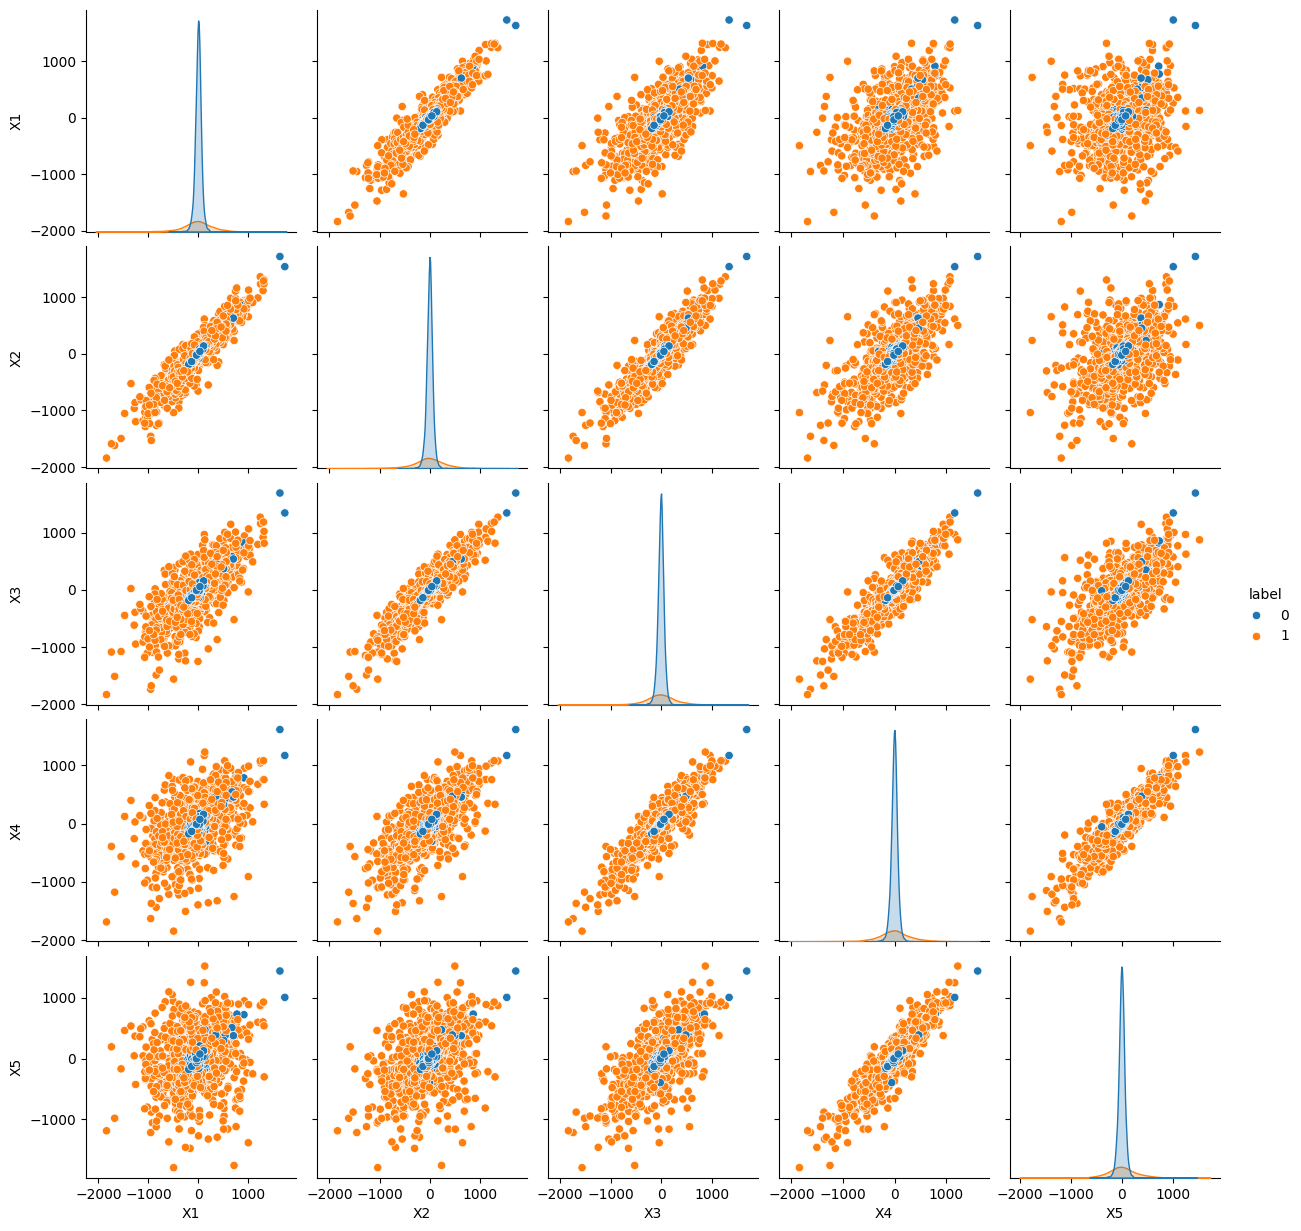

In [ ]:
# Para el gráfico de a pares, elegimos 5 features para observar 25 gráficos únicamente.
sns.pairplot(
    df_plot,
    hue='label',
    vars=['X1', 'X2', 'X3', 'X4', 'X5']
)

Interpretación: se observa claramente que la cantidad de ejemplos de la clase negativa (0) supera a la clase positiva (1). Observando la diagonal principal, se ve que la mayor parte de los ejemplos de ambas clases se encuentran centrados alrededor del 0. Por cómo se distribuyen los datos, si se implementara SVM, un límite de decisión lineal no separaría correctamente los datos.

# Selección de los modelos

Para elegir qué modelos de Machine Learning entrenar y validar su rendimiento, se debe comprender la naturaleza del conjunto de datos:
* **Tipos de datos**: numéricos enteros.
* **Cantidad de datos**: el dataset es mediano (11.500 ejemplos y 178 características + la etiqueta).
* **Distribución**: los datos se encuentran centrados alrededor del 0 y la cantidad de ejemplos de cada clase está desbalanceado.
* **Riesgo de overfitting**: hay una alta dimensionalidad de features y la cantidad de ejemplos puede ser baja para ciertos modelos. Si se selecciona uno muy complejo, el riesgo de sobreajuste aumentará.

Se entrenarán y evaluarán tres tipos de modelos para seleccionar el que presente mejor rendimiento:
1. **Regresión Logística**: modelo simple y efectivo para clasificación binaria.
2. **K-Nearest Neighbors**: modelo simple y efectivo para clasificación binaria.
3. **Support Vector Machine**: modelo más complejo pero también eficaz para clasificación binaria. De éste se implementarán dos versiones, SVM Lineal y SVM No Lineal

#### División del dataset en conjuntos de entrenamiento y testeo

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separamos el dataset en dos porciones: un 80% para entrenar al modelo y el 20% restante para testear su rendimiento sobre datos no vistos
X_train, X_test, y_train, y_test = train_test_split(df_data, df_label, test_size=0.20, train_size=0.80)

# Normalizamos los datos
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Imprimimos los tamaños de los datasets
print('Tamaño de los datasets:')
print('Entrenamiento:', X_train_scaled.shape)
print('Validacion:', X_test_scaled.shape)

Tamaño de los datasets:
Entrenamiento: (9200, 178)
Validacion: (2300, 178)


### 1. Regresión Logística

#### Entrenamiento
Parámetros del modelo:
* **max_iter=500**. Se aumenta la máxima cantidad de iteraciones porque la cantidad por defecto (100) no permite al algoritmo converger, dado que el dataset contiene muchos ejemplos.
* **class_weight='balanced'**. Permite al algoritmo ajustar automáticamente el peso de cada clase según la cantidad de muestras, ya que el conjunto de datos está desbalanceado, para evitar que ignore la clase minoritaria ("Crisis").

In [ ]:
# Paso 1 - Importar el módulo del modelo y la métrica de Accuracy
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Paso 2 - Crear una instancia del modelo fijando el hiperparámetro de iteraciones y del ajuste de pesos de las clases
logisticRegr = LogisticRegression(max_iter=500, class_weight='balanced')

# Paso 3 - Entrenar el modelo con el dataset de entrenamiento
logisticRegr.fit(X_train_scaled, y_train)

# Paso 4.1 - Crear predicciones para ejemplos de entrenamiento
y_train_predict = logisticRegr.predict(X_train_scaled)

# Paso 4.2 - Crear predicciones para ejemplos nuevos
y_test_predict = logisticRegr.predict(X_test_scaled)

#### Validación

**Accuracy**

In [ ]:
print("Accuracy de entrenamiento:",accuracy_score(y_train, y_train_predict))

Accuracy de entrenamiento: 0.72


In [ ]:
print("Accuracy de testeo:",accuracy_score(y_test, y_test_predict))

Accuracy de testeo: 0.6882608695652174


**Matriz de confusión**

In [ ]:
# Importamos la métrica de matriz de confusión
from sklearn.metrics import confusion_matrix

# Creamos un arreglo con las etiquetas y las predicciones
cm_train = np.array(confusion_matrix(y_train, y_train_predict, labels=[0,1]))

confusion_matrix_train = pd.DataFrame(cm_train, index=['No crisis (Real)', 'Crisis (Real)'], columns=['No crisis (Estimado)', 'Crisis (Estimado)'])

print('Matriz de confusión de entrenamiento:\n')
confusion_matrix_train

Matriz de confusión de entrenamiento:



,No crisis (Estimado),Crisis (Estimado)
No crisis (Real),5658,1719
Crisis (Real),857,966


In [ ]:
cm_test = np.array(confusion_matrix(y_test, y_test_predict, labels=[0,1]))

confusion_matrix_test = pd.DataFrame(cm_test, index=['No crisis (Real)', 'Crisis (Real)'], columns=['No crisis (Estimado)', 'Crisis (Estimado)'])

print('Matriz de confusión de testeo:\n')
confusion_matrix_test

Matriz de confusión de testeo:



,No crisis (Estimado),Crisis (Estimado)
No crisis (Real),1383,440
Crisis (Real),277,200


**Reporte de métricas sobre la matriz de confusión de testeo**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_predict))

              precision    recall  f1-score   support

           0       0.83      0.76      0.79      1823
           1       0.31      0.42      0.36       477

    accuracy                           0.69      2300
   macro avg       0.57      0.59      0.58      2300
weighted avg       0.73      0.69      0.70      2300



Interpretación:
- El entrenamiento y evaluación del modelo fue veloz.
- La exactitud sobre ambos datasets es baja para el contexto del problema, un 72% en entrenamiento y 68.8% en testeo no es aceptable. Sin embargo, esta métrica por sí sola puede resultar engañosa, es por ello que también se implementa la matriz de confusión.
- Observando las matrices de confusión, se puede concluir que el modelo comete más errores clasificando los ejemplos de la clase positiva "Crisis" que los de la clase negativa "No crisis". Observar que en validación, la cantidad de ejemplos erróneamente clasificados como clase negativa (277) superan a los clasificados correctamente como clase positiva (200), mientras que los ejemplos bien clasificados de la clase negativa (1383) superan mayormente los erróneos (440). Esto se explica por el desbalanceo del dataset y justifica que el Accuracy por sí solo no es una métrica confiable, en este escenario.
- El Recall del modelo sobre la clase positiva (1), que es la métrica que importa mejorar, es demasiado bajo.

### 2. K-Nearest Neighbors

#### Entrenamiento
Parámetros del modelo:
* **n_neighbors=5**. La cantidad de vecinos a considerar serán 5, porque es un valor de K pequeño necesario ya que el dataset está desbalanceado pero no lo suficientemente chico como para provocar sobreajuste a los datos.


In [ ]:
# Paso 1 - Importar módulo del modelo
from sklearn.neighbors import KNeighborsClassifier

# Paso 2 - Crear una instancia del modelo definiendo el hiperparámetro K
knnRegression = KNeighborsClassifier(n_neighbors=5)

# Paso 3 - Entrenar el modelo con el dataset de entrenamiento
knnRegression.fit(X_train_scaled, y_train)

# Paso 4.1 - Crear predicciones para el dataset de entrenamiento
y_train_predict = knnRegression.predict(X_train_scaled)

# Paso 4.2 - Crear predicciones para el dataset de testeo
y_test_predict = knnRegression.predict(X_test_scaled)

#### Validación

**Accuracy**

In [ ]:
print("Accuracy de entrenamiento:",accuracy_score(y_train, y_train_predict))

Accuracy de entrenamiento: 0.9389130434782609


In [ ]:
print("Accuracy de testeo:",accuracy_score(y_test, y_test_predict))

Accuracy de testeo: 0.9269565217391305


**Matriz de confusión**

In [ ]:
cm_train = np.array(confusion_matrix(y_train, y_train_predict, labels=[0,1]))

confusion_matrix_train = pd.DataFrame(cm_train, index=['No crisis (Real)', 'Crisis (Real)'], columns=['No crisis (Estimado)', 'Crisis (Estimado)'])

print('Matriz de confusión de entrenamiento:\n')
confusion_matrix_train

Matriz de confusión de entrenamiento:



,No crisis (Estimado),Crisis (Estimado)
No crisis (Real),7375,2
Crisis (Real),560,1263


In [ ]:
cm_test = np.array(confusion_matrix(y_test, y_test_predict, labels=[0,1]))

confusion_matrix_test = pd.DataFrame(cm_test, index=['No crisis (Real)', 'Crisis (Real)'], columns=['No crisis (Estimado)', 'Crisis (Estimado)'])

print('Matriz de confusión de testeo:\n')
confusion_matrix_test

Matriz de confusión de testeo:



,No crisis (Estimado),Crisis (Estimado)
No crisis (Real),1823,0
Crisis (Real),168,309


**Reporte de métricas sobre la matriz de confusión de testeo**

In [ ]:
print(classification_report(y_test, y_test_predict))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96      1823
           1       1.00      0.65      0.79       477

    accuracy                           0.93      2300
   macro avg       0.96      0.82      0.87      2300
weighted avg       0.93      0.93      0.92      2300



Interpretación:
- El entrenamiento y evaluación del modelo fue veloz.
- La exactitud sobre ambos datasets es más alta que en el modelo de Regresión Logística y muy cercano al requisito definido aunque no supera el umbral. Un 93.9% en entrenamiento y 92.7% en testeo es un mejor indicador.
- Observando las matrices de confusión, se puede decir que el modelo comete menos errores que en Regresión clasificando los ejemplos de la clase minoritaria "Crisis". En este caso, las estimaciones correctas de la clase positiva superan a las erróneas, 1263 y 309 ejemplos clasificados correctamente. Al igual que en Regresión, las clasificaciones correctas de ejemplos de la clase mayoritaria "No crisis" superan las incorrectas.
- La precisión del modelo sobre la clase positiva es muy alta aunque el Recall sigue siendo bajo, pero es considerablemente más alto que en Regersión Logística.

### 3.1 Support Vector Machine Lineal

#### Entrenamiento
Parámetros del modelo:
* **kernel='linear'**. Se inicia probando con un kernel lineal a pesar de la interpretación previa del gráfico de a pares que mostraba que la clasificación de los datos se resolvería mejor con un kernel no lineal. Esto se debe a que el SVM Lineal es el más simple y por el que siempre se recomienda empezar.
* **class_weight='balanced'**

In [ ]:
# Paso 1 - Importar el modelo
from sklearn.svm import SVC

# Paso 2 - Crear una instancia del modelo con un kernel lineal
svc_model = SVC(kernel='linear',  class_weight='balanced')

# Paso 3 - Entrenar el modelo
svc_model.fit(X_train_scaled, y_train)

# Paso 4.1 - Crear predicciones para el dataset de entrenamiento
y_train_predict = svc_model.predict(X_train_scaled)

# Paso 4.2 - Crear predicciones para el dataset de testeo
y_test_predict = svc_model.predict(X_test_scaled)

#### Validación

**Accuracy**

In [ ]:
print("Accuracy de entrenamiento:",accuracy_score(y_train, y_train_predict))

Accuracy de entrenamiento: 0.8564130434782609


In [ ]:
print("Accuracy de testeo:",accuracy_score(y_test, y_test_predict))

Accuracy de testeo: 0.8330434782608696


**Matriz de confusión**

In [ ]:
cm_train = np.array(confusion_matrix(y_train, y_train_predict, labels=[0,1]))

confusion_matrix_train = pd.DataFrame(cm_train, index=['No crisis (Real)', 'Crisis (Real)'], columns=['No crisis (Estimado)', 'Crisis (Estimado)'])

print('Matriz de confusión de entrenamiento:\n')
confusion_matrix_train

Matriz de confusión de entrenamiento:



,No crisis (Estimado),Crisis (Estimado)
No crisis (Real),7240,137
Crisis (Real),1184,639


In [ ]:
cm_test = np.array(confusion_matrix(y_test, y_test_predict, labels=[0,1]))

confusion_matrix_test = pd.DataFrame(cm_test, index=['No crisis (Real)', 'Crisis (Real)'], columns=['No crisis (Estimado)', 'Crisis (Estimado)'])

print('Matriz de confusión de testeo:\n')
confusion_matrix_test

Matriz de confusión de testeo:



,No crisis (Estimado),Crisis (Estimado)
No crisis (Real),1783,40
Crisis (Real),344,133


**Reporte de métricas sobre la matriz de confusión de testeo**

In [ ]:
print(classification_report(y_test, y_test_predict))

              precision    recall  f1-score   support

           0       0.84      0.98      0.90      1823
           1       0.77      0.28      0.41       477

    accuracy                           0.83      2300
   macro avg       0.80      0.63      0.66      2300
weighted avg       0.82      0.83      0.80      2300



Interpretación:
- El entrenamiento y evaluación del modelo fue más lento que los modelos anteriores.
- La exactitud sobre ambos datasets es alta, 85.6% en entrenamiento y 83.3% en testeo, pero baja en comparación con el requisito de Accuracy definido en los objetivos del modelo.
- Observando las matrices de confusión, se ve que el modelo comete pocos errores al clasificar los ejemplos de la clase mayoritaria "No Crisis". Sin embargo, como en Regresión, las estimaciones incorrectas sobre los ejemplos de la clase minoritaria "Crisis" superan a las clasificaciones correctas (1184 y 344 ejemplos mal clasificados).
- La precisión del modelo sobre la clase positiva es muy alta pero el Recall absolutamente bajo. El "Trade-Off" entre estas dos métricas es similar al observado en Regresión Logística.

### 3.2 Support Vector Machine No Lineal

#### Entrenamiento
Parámetros del modelo:
* **kernel='rbf'**. Se implementará el kernel no lineal RBF Gaussiano porque permite adaptarse a límites de decisión con estructuras complejas.
* **class_weight='balanced'**

In [ ]:
# Crear una instancia del modelo con un kernel RBF Gaussiano
svc_model = SVC(kernel='rbf', class_weight='balanced')

# Entrenar el modelo
svc_model.fit(X_train_scaled, y_train)

# Crear predicciones para el dataset de entrenamiento
y_train_predict = svc_model.predict(X_train_scaled)

# Crear predicciones para el dataset de testeo
y_test_predict = svc_model.predict(X_test_scaled)

#### Validación

**Accuracy**

In [ ]:
print("Accuracy de entrenamiento:",accuracy_score(y_train, y_train_predict))

Accuracy de entrenamiento: 0.9821739130434782


In [ ]:
print("Accuracy de testeo:",accuracy_score(y_test, y_test_predict))

Accuracy de testeo: 0.9795652173913043


**Matriz de confusión**

In [ ]:
cm_train = np.array(confusion_matrix(y_train, y_train_predict, labels=[0,1]))

confusion_matrix_train = pd.DataFrame(cm_train, index=['No crisis (Real)', 'Crisis (Real)'], columns=['No crisis (Estimado)', 'Crisis (Estimado)'])

print('Matriz de confusión de entrenamiento:\n')
confusion_matrix_train

Matriz de confusión de entrenamiento:



,No crisis (Estimado),Crisis (Estimado)
No crisis (Real),7238,139
Crisis (Real),25,1798


In [ ]:
cm_test = np.array(confusion_matrix(y_test, y_test_predict, labels=[0,1]))

confusion_matrix_test = pd.DataFrame(cm_test, index=['No crisis (Real)', 'Crisis (Real)'], columns=['No crisis (Estimado)', 'Crisis (Estimado)'])

print('Matriz de confusión de testeo:\n')
confusion_matrix_test

Matriz de confusión de testeo:



,No crisis (Estimado),Crisis (Estimado)
No crisis (Real),1803,20
Crisis (Real),27,450


**Reporte de métricas sobre la matriz de confusión de testeo**

In [ ]:
print(classification_report(y_test, y_test_predict))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1823
           1       0.96      0.94      0.95       477

    accuracy                           0.98      2300
   macro avg       0.97      0.97      0.97      2300
weighted avg       0.98      0.98      0.98      2300



Interpretación:
- El entrenamiento y evaluación del modelo fue más lento que los modelos anteriores, similar al SVM Lineal.
- La exactitud sobre ambos datasets cumple con el requisito planteado en la definición de los objetivos, 98.2% en entrenamiento y 98% en testeo supera el umbral definido.
- Observando las diagonales principales de las matrices de confusión, se confirma que el modelo realiza más clasificaciones correctas que incorrectas. Tanto los ejemplos de actividades cerebrales que presentaban crisis epilépticas como los que no, fueron en su mayoría correctamente categorizados.
- La precisión del modelo sobre la clase positiva es muy alta y el Recall también lo es. Este es el primer modelo que cumple con el requisito de alcanzar un Recall alto.

# Conclusión

El modelo seleccionado para resolver el problema de clasificación binaria es: **SVM No Lineal**.

La elección se debe a que éste modelo cumplió con dos de los tres requisitos planteados, alcanzar una alta exactitud y Recall. Aunque los modelos más simples de Regresión Logística y K-Nearest Neighbors presentan una ventaja sobre éste en cuanto a la velocidad en la elaboración de las predicciones, la velocidad de ejecución del modelo de SVM No Lineal es aceptable, además de que su capacidad supera al resto de algoritmos evaluados.

El modelo seleccionado es el único que mantiene un alto rendimiento global y logra una detección muy alta de los ejemplos de la clase positiva "Crisis", que es el objetivo principal del problema.